In [1]:
pip install "dask[complete]"

In [2]:
pip install dask-ml

In [2]:
# 1. Imports
import dask.dataframe as dd
from dask.distributed import Client
import xgboost as xgb
from dask_ml.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [6]:
# 2. Start Dask client
client = Client()
print(client)

/usr/local/lib/python3.12/dist-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 33857 instead
  warnings.warn(
INFO:distributed.scheduler:State start
INFO:distributed.scheduler:  Scheduler at:     tcp://127.0.0.1:43727
INFO:distributed.scheduler:  dashboard at:  http://127.0.0.1:33857/status
INFO:distributed.scheduler:Registering Worker plugin shuffle
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:35827'
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:35607'
INFO:distributed.scheduler:Register worker addr: tcp://127.0.0.1:40989 name: 1
INFO:distributed.scheduler:Starting worker compute stream, tcp://127.0.0.1:40989
INFO:distributed.core:Starting established connection to tcp://127.0.0.1:53588
INFO:distributed.scheduler:Register worker addr: tcp://127.0.0.1:36627 name: 0
INFO:distributed.scheduler:Starting worker compute stream, tcp://127.0.0.1:36627
IN

<Client: 'tcp://127.0.0.1:43727' processes=2 threads=2, memory=12.67 GiB>


In [7]:
# 3. Load dataset
# Columns: order_id, user_id, order_number, product_name, reordered
df = dd.read_csv(
    "full_file.csv",
    dtype={
        'add_to_cart_order': 'float64',
        'order_dow': 'float64',
        'order_hour_of_day': 'float64',
        'order_number': 'float64',
        'product_id': 'float64',
        'reordered': 'float64'
    }
)

In [8]:
print(df.shape[0].compute())

11160636


In [9]:
df.head()

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_id,add_to_cart_order,reordered,product_name,aisle,department
0,473747,1,prior,3.0,3.0,12.0,21.0,10258.0,3.0,1.0,Pistachios,nuts seeds dried fruit,snacks
1,473747,1,prior,3.0,3.0,12.0,21.0,25133.0,4.0,0.0,Organic String Cheese,packaged cheese,dairy eggs
2,473747,1,prior,3.0,3.0,12.0,21.0,30450.0,5.0,0.0,Creamy Almond Butter,spreads,pantry
3,431534,1,prior,5.0,4.0,15.0,28.0,196.0,1.0,1.0,Soda,soft drinks,beverages
4,431534,1,prior,5.0,4.0,15.0,28.0,12427.0,2.0,1.0,Original Beef Jerky,popcorn jerky,snacks


In [10]:
df_small = df[['order_id', 'user_id', 'product_name']]

In [11]:
df_small.head()

,order_id,user_id,product_name
0,473747,1,Pistachios
1,473747,1,Organic String Cheese
2,473747,1,Creamy Almond Butter
3,431534,1,Soda
4,431534,1,Original Beef Jerky


In [12]:
df_small['product_name'] = df_small['product_name'].str.lower()

In [13]:
df = (
    df_small
    .categorize(columns=['user_id', 'product_name'])
    .persist()
)

In [14]:
df = df.astype({
    "user_id": "int64",
    "order_id": "int64",
    "product_name": "string"
})

In [15]:
df.head()

,order_id,user_id,product_name
0,473747,1,pistachios
1,473747,1,organic string cheese
2,473747,1,creamy almond butter
3,431534,1,soda
4,431534,1,original beef jerky


In [16]:
# Step 1: Compute and aggregate products per order for each user
orders_products = df.groupby(['user_id', 'order_id'])['product_name'].apply(list).compute()

/tmp/ipykernel_53253/3961388644.py:2: UserWarning: `meta` is not specified, inferred from partial data.
Please provide `meta` if the result is unexpected.
  Before: .apply(func)
  After:  .apply(func, meta={'x': 'f8', 'y': 'f8'}) for dataframe result
  or:     .apply(func, meta=('x', 'f8'))            for series result

  orders_products = df.groupby(['user_id', 'order_id'])['product_name'].apply(list).compute()


In [17]:
orders_products = orders_products.reset_index()

In [19]:
orders_products.head()

,user_id,order_id,product_name
0,32,72626,"[organic snipped green beans, single serve cri..."
1,32,134879,"[organic smoked turkey breast, organic thyme, ..."
2,87,88090,"[milk, organic, vitamin d]"
3,87,122960,"[organic large brown grade aa cage free eggs, ..."
4,87,161814,"[bread, country buttermilk, original low fat o..."


In [20]:
# Step 2: Sort orders by user and order_id to find next order info
orders_products = orders_products.sort_values(['user_id', 'order_id'])

# Add next order_id and next order products per user
orders_products['next_order_id'] = orders_products.groupby('user_id')['order_id'].shift(-1)
orders_products['next_products'] = orders_products.groupby('user_id')['product_name'].shift(-1)

In [23]:
orders_products.head()

,user_id,order_id,product_name,next_order_id,next_products
348337,1,431534,"[soda, original beef jerky, pistachios, organi...",473747.0,"[pistachios, organic string cheese, creamy alm..."
348338,1,473747,"[pistachios, organic string cheese, creamy alm...",550135.0,"[original beef jerky, organic string cheese, c..."
348339,1,550135,"[original beef jerky, organic string cheese, c...",1187899.0,"[soda, xl pick-a-size paper towel rolls, pista..."
348340,1,1187899,"[soda, xl pick-a-size paper towel rolls, pista...",NaN,NaN
140045,2,738281,"[chipotle beef & pork realstick, hommus classi...",788338.0,"[organic hass avocado, blueberry yoghurt, rasp..."


In [24]:
# Step 3: Explode products in current order to get one row per product
orders_products_expanded = orders_products.explode('product_name').reset_index(drop=True)

In [25]:
orders_products_expanded.head()

,user_id,order_id,product_name,next_order_id,next_products
0,1,431534,soda,473747.0,"[pistachios, organic string cheese, creamy alm..."
1,1,431534,original beef jerky,473747.0,"[pistachios, organic string cheese, creamy alm..."
2,1,431534,pistachios,473747.0,"[pistachios, organic string cheese, creamy alm..."
3,1,431534,organic fuji apples,473747.0,"[pistachios, organic string cheese, creamy alm..."
4,1,431534,honeycrisp apples,473747.0,"[pistachios, organic string cheese, creamy alm..."


In [26]:
# Step 4: Define label: 1 if product appears in next order, else 0
def label(row):
    # If product_name is missing, label 0
    if pd.isna(row['product_name']):
        return 0

    next_prods = row['next_products']

    # Handle missing / non-iterable next_products
    if not isinstance(next_prods, (list, tuple, set, pd.Series, np.ndarray)):
        return 0

    # Convert to list safely
    next_list = list(next_prods)

    # Safe membership check
    return 1 if row['product_name'] in next_list else 0

orders_products_expanded['label'] = orders_products_expanded.apply(label, axis=1)

INFO:distributed.core:Event loop was unresponsive in Nanny for 4.18s.  This is often caused by long-running GIL-holding functions or moving large chunks of data. This can cause timeouts and instability.
INFO:distributed.core:Event loop was unresponsive in Scheduler for 4.20s.  This is often caused by long-running GIL-holding functions or moving large chunks of data. This can cause timeouts and instability.
INFO:distributed.core:Event loop was unresponsive in Nanny for 4.21s.  This is often caused by long-running GIL-holding functions or moving large chunks of data. This can cause timeouts and instability.
INFO:distributed.core:Event loop was unresponsive in Scheduler for 3.49s.  This is often caused by long-running GIL-holding functions or moving large chunks of data. This can cause timeouts and instability.
INFO:distributed.core:Event loop was unresponsive in Nanny for 3.52s.  This is often caused by long-running GIL-holding functions or moving large chunks of data. This can cause tim

In [28]:
orders_products_expanded.head()

,user_id,order_id,product_name,next_order_id,next_products,label
0,1,431534,soda,473747.0,"[pistachios, organic string cheese, creamy alm...",1
1,1,431534,original beef jerky,473747.0,"[pistachios, organic string cheese, creamy alm...",1
2,1,431534,pistachios,473747.0,"[pistachios, organic string cheese, creamy alm...",1
3,1,431534,organic fuji apples,473747.0,"[pistachios, organic string cheese, creamy alm...",0
4,1,431534,honeycrisp apples,473747.0,"[pistachios, organic string cheese, creamy alm...",0


In [29]:
# Step 5: Encode categorical features
orders_products_expanded['product_cat'] = orders_products_expanded['product_name'].astype('category').cat.codes
orders_products_expanded['user_cat'] = orders_products_expanded['user_id'].astype('category').cat.codes

In [30]:
orders_products_expanded.head()

,user_id,order_id,product_name,next_order_id,next_products,label,product_cat,user_cat
0,1,431534,soda,473747.0,"[pistachios, organic string cheese, creamy alm...",1,40577,0
1,1,431534,original beef jerky,473747.0,"[pistachios, organic string cheese, creamy alm...",1,32137,0
2,1,431534,pistachios,473747.0,"[pistachios, organic string cheese, creamy alm...",1,34359,0
3,1,431534,organic fuji apples,473747.0,"[pistachios, organic string cheese, creamy alm...",0,29407,0
4,1,431534,honeycrisp apples,473747.0,"[pistachios, organic string cheese, creamy alm...",0,20000,0


In [31]:
import numpy as np
from sklearn.model_selection import train_test_split

# Step 6: SPLIT USERS TO AVOID LEAKAGE

# 1️⃣ Ensure user_id is clean: drop missing values and convert to string
orders_products_expanded['user_id_str'] = orders_products_expanded['user_id'].astype(str)

# 2️⃣ Get unique users as a clean NumPy array
unique_users = orders_products_expanded['user_id_str'].dropna().unique()
unique_users = np.array(unique_users, dtype=str)  # explicitly make 1D array of strings

# 3️⃣ Split users into train and test
train_users, test_users = train_test_split(
    unique_users,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

# 4️⃣ Filter the dataset by user_id to create train and test sets
train_df = orders_products_expanded[orders_products_expanded['user_id_str'].isin(train_users)].copy()
test_df = orders_products_expanded[orders_products_expanded['user_id_str'].isin(test_users)].copy()

# Optional: Drop the helper column if you want
train_df = train_df.drop(columns=['user_id_str'])
test_df = test_df.drop(columns=['user_id_str'])

# ✅ Now train_df and test_df have no user leakage

INFO:distributed.core:Event loop was unresponsive in Scheduler for 7.20s.  This is often caused by long-running GIL-holding functions or moving large chunks of data. This can cause timeouts and instability.
INFO:distributed.core:Event loop was unresponsive in Nanny for 7.21s.  This is often caused by long-running GIL-holding functions or moving large chunks of data. This can cause timeouts and instability.
INFO:distributed.core:Event loop was unresponsive in Nanny for 7.21s.  This is often caused by long-running GIL-holding functions or moving large chunks of data. This can cause timeouts and instability.
INFO:distributed.core:Event loop was unresponsive in Nanny for 7.20s.  This is often caused by long-running GIL-holding functions or moving large chunks of data. This can cause timeouts and instability.
INFO:distributed.core:Event loop was unresponsive in Nanny for 7.21s.  This is often caused by long-running GIL-holding functions or moving large chunks of data. This can cause timeout

In [32]:
train_df.head()

,user_id,order_id,product_name,next_order_id,next_products,label,product_cat,user_cat
0,1,431534,soda,473747.0,"[pistachios, organic string cheese, creamy alm...",1,40577,0
1,1,431534,original beef jerky,473747.0,"[pistachios, organic string cheese, creamy alm...",1,32137,0
2,1,431534,pistachios,473747.0,"[pistachios, organic string cheese, creamy alm...",1,34359,0
3,1,431534,organic fuji apples,473747.0,"[pistachios, organic string cheese, creamy alm...",0,29407,0
4,1,431534,honeycrisp apples,473747.0,"[pistachios, organic string cheese, creamy alm...",0,20000,0


In [33]:
test_df.head()

,user_id,order_id,product_name,next_order_id,next_products,label,product_cat,user_cat
134,5,157374,plain whole milk yogurt,2196797.0,"[organic raw agave nectar, sharp cheddar chees...",0,34513,4
135,5,157374,red raspberries,2196797.0,"[organic raw agave nectar, sharp cheddar chees...",0,36984,4
136,5,157374,uncured genoa salami,2196797.0,"[organic raw agave nectar, sharp cheddar chees...",0,45753,4
137,5,157374,organic grape tomatoes,2196797.0,"[organic raw agave nectar, sharp cheddar chees...",1,29563,4
138,5,157374,large organic omega3 brown eggs,2196797.0,"[organic raw agave nectar, sharp cheddar chees...",0,21991,4


In [34]:
# Step 7: Prepare train/test data
X_train = train_df[['product_cat', 'user_cat']]
y_train = train_df['label']

X_test = test_df[['product_cat', 'user_cat']]
y_test = test_df['label']

In [35]:
# Step 8: Train XGBoost model
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()# to makeit more sensitive to rerderasmost are not reordered
model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', scale_pos_weight=scale_pos_weight)
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [12:34:56] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [36]:
 #Step 9: Predict and evaluate
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy:.4f}")

Test Accuracy: 0.6305


In [48]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[1229553  619336]
 [ 208839  183582]]


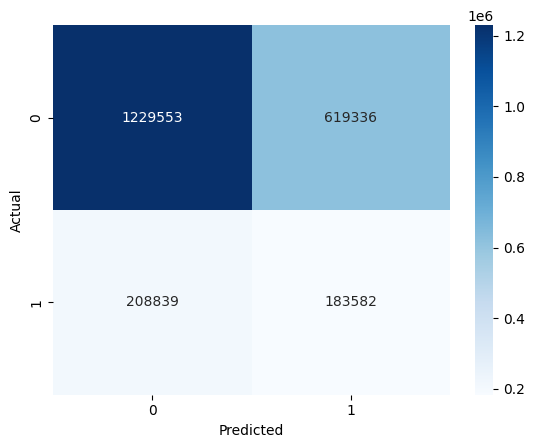

In [38]:
import seaborn as sns

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [39]:
print("ROC AUC:", roc_auc_score(y_test, model.predict_proba(X_test)[:,1]))

ROC AUC: 0.5928806898888209


In [40]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

In [41]:
print(precision)
print(recall)
print(f1)

0.22864352275076658
0.467819000512205
0.30716307256769837


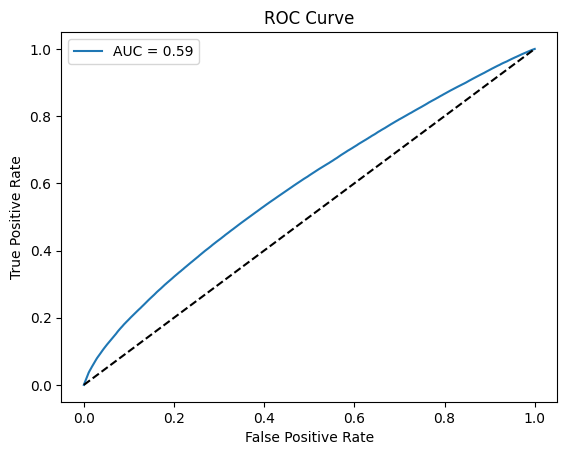

In [42]:
from sklearn.metrics import roc_curve, roc_auc_score

probs = model.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, probs)
roc_auc = roc_auc_score(y_test, probs)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [43]:
#label is repeat rate, fraction of times it was reordered

In [44]:
repeat_rates = orders_products_expanded.groupby('product_name')['label'].mean()
repeat_rates = repeat_rates.sort_values(ascending=False)
repeat_rates.head(10)

,label
product_name,
soy crisps lightly salted,0.833333
"coffee, ground, medium, special roast",0.800000
organic raspberry black tea,0.750000
orange flavored sports drink,0.750000
100% unsweetened honeysuckle natural iced white tea,0.714286
benchbreak chardonnay,0.702703
chocolate love bar,0.689655
zero peach nutrient enhanced water beverage,0.666667
tropical turmeric jun-kombucha made with honey organic,0.666667


In [ ]:
# identifying better threshold

In [54]:
from sklearn.metrics import precision_recall_curve

probs = model.predict_proba(X_test)[:,1]
precision, recall, thresholds = precision_recall_curve(y_test, probs)

# Compute F1 scores for all thresholds
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)  # small epsilon to avoid div by zero

# Find threshold with max F1
best_idx = f1_scores.argmax()
best_threshold = thresholds[best_idx]

print(f"Best threshold by F1 score: {best_threshold:.3f}")

Best threshold by F1 score: 0.473


In [55]:
probs = model.predict_proba(X_test)[:,1]

# Apply custom threshold
custom_threshold = best_threshold  # from step above, e.g., 0.3 or 0.4
y_pred_custom = (probs >= 0.473).astype(int)

In [56]:
accuracy = accuracy_score(y_test, y_pred_custom)
print(f"Test Accuracy: {accuracy:.4f}")

Test Accuracy: 0.5321


In [57]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_custom)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[953300 895589]
 [153039 239382]]


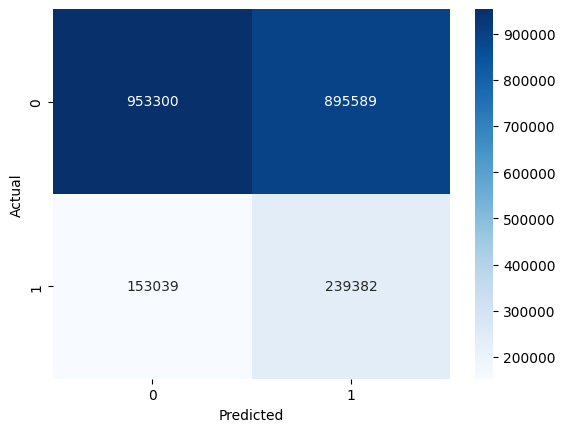

In [58]:
import seaborn as sns

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [59]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test, y_pred_custom)
recall = recall_score(y_test, y_pred_custom)
f1 = f1_score(y_test, y_pred_custom)

In [60]:
print(precision)
print(recall)
print(f1)

0.2109146401097473
0.6100132255919025
0.31345194946680355
